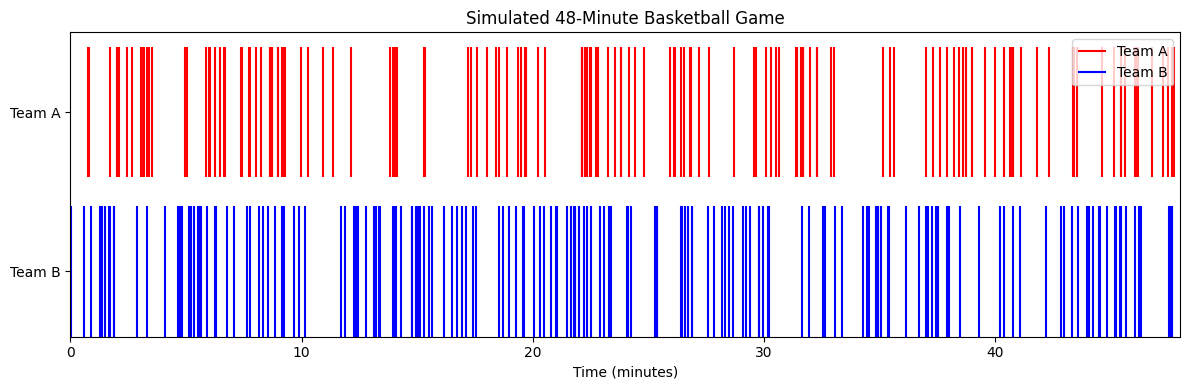

In [1]:
#problem 2c
import numpy as np
import matplotlib.pyplot as plt

#parameters
lam = 3         
T = 48         
rng = np.random.default_rng(777)  

#simulate arrival times
def simulate_poisson_arrivals(rate, T, rng):
    times = []
    t = 0.0
    
    while True:
        t += rng.exponential(1 / rate)  
        if t > T:
            break
        times.append(t)
    
    return np.array(times)

#simulate scoring times for each team
times_A = simulate_poisson_arrivals(lam, T, rng)
times_B = simulate_poisson_arrivals(lam, T, rng)

#plot vertical bars
plt.figure(figsize=(12, 4))

#team A: red bars from y=0.55 to y=1.0
plt.vlines(times_A, ymin=0.55, ymax=1.0, color='red', label='Team A')

#team B: blue bars from y=0.0 to y=0.45
plt.vlines(times_B, ymin=0.0, ymax=0.45, color='blue', label='Team B')

#plot
plt.xlim(0, T)
plt.ylim(0, 1.05)
plt.xlabel("Time (minutes)")
plt.title("Simulated 48-Minute Basketball Game")
plt.yticks([0.225, 0.775], ["Team B", "Team A"])
plt.legend()
plt.tight_layout()
plt.savefig("hw7-pbm2c.png",dpi=300, bbox_inches="tight")
plt.show()

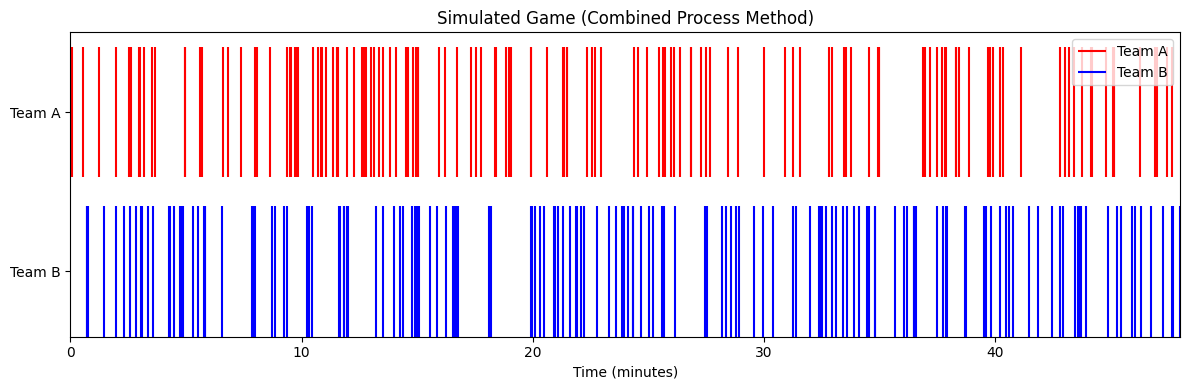

In [2]:
#problem 2d

#comined poisson process
def combined_process(lam, T, rng):
    rate = 2 * lam   #combined rate
    t = 0.0
    times_A = []
    times_B = []
    
    while True:
        t += rng.exponential(1 / rate)
        if t > T:
            break
        
        #assign basket to A or B
        if rng.random() < 0.5:
            times_A.append(t)
        else:
            times_B.append(t)
    
    return np.array(times_A), np.array(times_B)

#simulate
times_A, times_B = combined_process(lam, T, rng)

#plot
plt.figure(figsize=(12, 4))

plt.vlines(times_A, ymin=0.55, ymax=1.0, color='red', label='Team A')
plt.vlines(times_B, ymin=0.0, ymax=0.45, color='blue', label='Team B')

plt.xlim(0, T)
plt.ylim(0, 1.05)
plt.xlabel("Time (minutes)")
plt.title("Simulated Game (Combined Process Method)")
plt.yticks([0.225, 0.775], ["Team B", "Team A"])
plt.legend()
plt.tight_layout()
plt.savefig("hw7-pbm2d.png",dpi=300, bbox_inches="tight")
plt.show()

In [4]:
#problem 2e
from scipy.special import i0

#params
lam = 3
t = 48
n_games = 10**5
rng = np.random.default_rng(777)

#simulate total baskets in each game
N = rng.poisson(2 * lam * t, size=n_games)

#simulate baskets by team A conditional on total
NA = rng.binomial(N, 0.5)

#team B baskets
NB = N - NA

#difference
D = 2 * (NA - NB)

#estimates
mean_est = np.mean(D)
var_est = np.var(D, ddof=0)
tie_est = np.mean(D == 0)

#theoretical values
mean_theory = 0
var_theory = 8 * lam * t
tie_theory = np.exp(-2 * lam * t) * i0(2 * lam * t)

print(f"estimated expectation     = {mean_est:.4f}")
print(f"theoretical expectation   = {mean_theory:.4f}")
print()

print(f"estimated variance   = {var_est:.4f}")
print(f"theoretical variance = {var_theory:.4f}")
print()

print(f"estimated P(D(48)=0)   = {tie_est:.6f}")
print(f"theoretical P(D(48)=0) = {tie_theory:.6f}")

estimated expectation     = 0.0755
theoretical expectation   = 0.0000

estimated variance   = 1148.8567
theoretical variance = 1152.0000

estimated P(D(48)=0)   = 0.023680
theoretical P(D(48)=0) = 0.023518
